# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Jajang Didin
- **Email:** jajangdidin007@gmail.com
- **ID Dicoding:** Jajang Didin

## Menentukan Pertanyaan Bisnis

- Bagaimana tren fluktuasi total penyewaan sepeda secara bulanan sepanjang tahun 2012, dan pada bulan apa lonjakan permintaan tertinggi terjadi, agar perusahaan dapat mengoptimalkan alokasi ketersediaan armada sepeda dan menyusun strategi kampanye musiman?

- Bagaimana perbedaan proporsi jumlah penyewaan antara pelanggan terdaftar (registered) dan pelanggan kasual (casual) pada hari kerja dibandingkan dengan hari libur/akhir pekan, guna merancang penawaran diskon khusus atau program konversi membership yang tepat sasaran?

## Import Semua Packages/Library yang Digunakan

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [58]:
# Memuat data day.csv
day_df = pd.read_csv("Bike-sharing-dataset/day.csv")

# Menampilkan 5 baris pertama dari day_df untuk memastikan data berhasil dimuat
display(day_df.head())

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [59]:
# Memuat data hour.csv
hour_df = pd.read_csv("Bike-sharing-dataset/hour.csv")

# Menampilkan 5 baris pertama dari hour_df untuk memastikan data berhasil dimuat
display(hour_df.head())

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- day_df: Dataset ini berisi informasi penyewaan sepeda yang direkapitulasi dalam skala harian (total 731 hari).
- hour_df: Dataset ini berisi informasi penyewaan sepeda yang direkapitulasi dalam skala per jam (total 17.379 jam).

### Assessing Data

Menilai data day_df

In [60]:
# Memeriksa tipe data dan informasi umum dari day_df
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [61]:
# Memeriksa jumlah missing value di day_df
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [62]:
# Memeriksa jumlah duplikasi data di day_df
print("\nJumlah Duplikasi di day_df:", day_df.duplicated().sum())

# Melihat parameter statistik dasar dari day_df
day_df.describe()


Jumlah Duplikasi di day_df: 0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Menilai data hour_df

In [63]:
# Memeriksa tipe data dan informasi umum dari hour_df
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [64]:
# Memeriksa jumlah missing value di hour_df
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [65]:
# Memeriksa jumlah duplikasi data di hour_df
print("\nJumlah Duplikasi di hour_df:", hour_df.duplicated().sum())

# Melihat parameter statistik dasar dari hour_df
hour_df.describe()


Jumlah Duplikasi di hour_df: 0


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Pada day_df:Tidak ditemukan adanya missing value (data kosong/NaN) pada seluruh kolom.Tidak ditemukan adanya data duplikat (baris ganda).Tipe data pada kolom dteday (tanggal) masih berupa object (string), yang mana seharusnya adalah datetime.Parameter statistik (seperti rata-rata, min, max) menunjukkan nilai yang wajar dan tidak mengindikasikan adanya outlier atau anomali pencatatan yang salah.
- Pada hour_df: Sama seperti data harian, tidak ditemukan missing value maupun data duplikat pada data per jam ini.Tipe data kolom dteday juga masih berupa object (string) dan perlu diperbaiki.Parameter statistik numerik juga aman dan logis sesuai dengan konteks bisnis penyewaan sepeda.

### Cleaning Data

In [66]:
# 1. Mengubah tipe data 'dteday' menjadi datetime untuk dataset day_df
day_df["dteday"] = pd.to_datetime(day_df["dteday"])

# 2. Memetakan nilai angka menjadi teks deskriptif pada day_df
day_df['season'] = day_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
day_df['yr'] = day_df['yr'].map({0: '2011', 1: '2012'})
day_df['weathersit'] = day_df['weathersit'].map({1: 'Clear/Partly Cloudy',
                                                 2: 'Misty/Cloudy',
                                                 3: 'Light Snow/Rain',
                                                 4: 'Severe Weather'})

# 4. Memeriksa kembali tipe data dteday untuk memastikan sudah berubah
print('Tipe data dteday pada day_df:', day_df["dteday"].dtypes)

# 5. Menampilkan 5 baris pertama data day_df yang sudah dibersihkan
display(day_df.head())

Tipe data dteday pada day_df: datetime64[ns]


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,1,0,6,0,Misty/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,1,0,0,0,Misty/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,1,0,1,1,Clear/Partly Cloudy,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,1,0,2,1,Clear/Partly Cloudy,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,1,0,3,1,Clear/Partly Cloudy,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [67]:
# Mengubah tipe data 'dteday' menjadi datetime untuk dataset hour_df
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

# Memetakan nilai angka menjadi teks deskriptif pada hour_df
hour_df['season'] = hour_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
hour_df['yr'] = hour_df['yr'].map({0: '2011', 1: '2012'})
hour_df['weathersit'] = hour_df['weathersit'].map({1: 'Clear/Partly Cloudy',
                                                   2: 'Misty/Cloudy',
                                                   3: 'Light Snow/Rain',
                                                   4: 'Severe Weather'})

# 4. Memeriksa kembali tipe data dteday untuk memastikan sudah berubah
print('Tipe data dteday pada hour_df:', hour_df["dteday"].dtypes)

Tipe data dteday pada hour_df: datetime64[ns]


In [68]:
# Menampilkan 5 baris pertama data hour_df yang sudah dibersihkan
display(hour_df.head())

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,1,0,0,6,0,Clear/Partly Cloudy,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,1,1,0,6,0,Clear/Partly Cloudy,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,1,2,0,6,0,Clear/Partly Cloudy,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,1,3,0,6,0,Clear/Partly Cloudy,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,1,4,0,6,0,Clear/Partly Cloudy,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Berdasarkan temuan pada tahap Assessing Data, langkah pembersihan difokuskan pada perbaikan tipe data dan format nilai agar siap untuk divisualisasikan :
  1. Memperbaiki Tipe Data: Kolom dteday pada day_df maupun hour_df telah berhasil diubah dari tipe object menjadi tipe datetime agar analisis berdasarkan runtut waktu (time-series) dapat dilakukan dengan akurat.
  2. Memetakan Nilai Kategori (Mapping): Untuk mempermudah proses visualisasi dan pembacaan grafik nantinya, nilai angka pada kolom season (musim), yr (tahun), dan weathersit (kondisi cuaca) pada kedua dataset telah diubah menjadi teks deskriptif (misalnya: musim 1 menjadi 'Spring', tahun 0 menjadi '2011').
  3. Catatan Penting: Karena pada tahap Assessing tidak ditemukan missing value maupun duplicate data pada day_df dan hour_df, maka teknik penanganan seperti dropping (dropna, drop_duplicates) atau imputation tidak diperlukan dalam proyek ini.


## Exploratory Data Analysis (EDA)

### Explore ...

In [69]:
# Eksplorasi Parameter Statistik Dasar
# Melihat ringkasan nilai rata-rata, kuartil, nilai minimum dan maksimum
display(day_df.describe(include="all"))

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731,731,731.000000,731.000000,731.000000,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,NaN,4,2,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,2012,NaN,NaN,NaN,NaN,Clear/Partly Cloudy,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,188,366,NaN,NaN,NaN,NaN,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,2012-01-01 00:00:00,NaN,NaN,6.519836,0.028728,2.997264,0.683995,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,NaN,NaN,1.000000,0.000000,0.000000,0.000000,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,NaN,NaN,4.000000,0.000000,1.000000,0.000000,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,NaN,NaN,7.000000,0.000000,3.000000,1.000000,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,NaN,NaN,10.000000,0.000000,5.000000,1.000000,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,NaN,NaN,12.000000,1.000000,6.000000,1.000000,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [70]:
# 1. Memfilter data khusus tahun 2012
# Menggunakan tanda kutip '2012' karena pada tahap Data Cleaning sebelumnya angka sudah diubah menjadi string
df_2012 = day_df[day_df['yr'] == '2012']

# 2. Mengelompokkan total penyewaan (cnt) berdasarkan bulan (mnth)
rentals_per_month_2012 = df_2012.groupby(by='mnth').agg({
    'cnt': 'sum'
}).reset_index()

# 3. Mengurutkan data dari yang paling tinggi ke rendah untuk mencari Peak Month
peak_month_data = rentals_per_month_2012.sort_values(by='cnt', ascending=False)

# Menampilkan hasil eksplorasi
print("Total Penyewaan Sepeda per Bulan di Tahun 2012:")
display(rentals_per_month_2012)

print("\nBulan dengan Penyewaan Tertinggi (Puncak Permintaan):")
display(peak_month_data.head(1))

Total Penyewaan Sepeda per Bulan di Tahun 2012:


,mnth,cnt
0,1,96744
1,2,103137
2,3,164875
3,4,174224
4,5,195865
5,6,202830
6,7,203607
7,8,214503
8,9,218573
9,10,198841



Bulan dengan Penyewaan Tertinggi (Puncak Permintaan):


,mnth,cnt
8,9,218573


In [71]:
# 1. Mengelompokkan TOTAL penyewaan tipe pelanggan berdasarkan tipe hari (workingday)
# Menggunakan 'sum' (total) bukan 'mean' (rata-rata) agar bisa dihitung persentasenya
user_behavior = day_df.groupby(by='workingday').agg({
    'casual': 'sum',
    'registered': 'sum'
}).reset_index()

# 2. Menghitung total keseluruhan penyewaan (casual + registered) per baris
user_behavior['total_rentals'] = user_behavior['casual'] + user_behavior['registered']

# 3. Menghitung PERSENTASE untuk menjawab pertanyaan bisnis yang measurable
user_behavior['casual_percentage (%)'] = round((user_behavior['casual'] / user_behavior['total_rentals']) * 100, 2)
user_behavior['registered_percentage (%)'] = round((user_behavior['registered'] / user_behavior['total_rentals']) * 100, 2)

# 4. Mengubah angka 0 dan 1 menjadi label teks yang mudah dibaca di tabel
user_behavior['workingday'] = user_behavior['workingday'].map({
    0: 'Hari Libur / Akhir Pekan',
    1: 'Hari Kerja'
})

# Menampilkan hasil eksplorasi
print("Eksplorasi Persentase Penyewaan: Casual vs Registered (2011-2012):")
display(user_behavior)

Eksplorasi Persentase Penyewaan: Casual vs Registered (2011-2012):


,workingday,casual,registered,total_rentals,casual_percentage (%),registered_percentage (%)
0,Hari Libur / Akhir Pekan,316732,683537,1000269,31.66,68.34
1,Hari Kerja,303285,1989125,2292410,13.23,86.77


**Insight:**

**1. Analisis Tren Penyewaan Tahun 2012:**
* Jumlah penyewaan sepeda tidak berjalan stagnan, melainkan mengalami fluktuasi yang cukup dinamis setiap bulannya.
* Puncak permintaan tertinggi (*Peak Season*) pada tahun 2012 terjadi pada bulan **September** (memasuki musim gugur). Fakta data ini sangat krusial bagi tim operasional untuk mulai mempersiapkan ketersediaan armada (sepeda dan stasiun) secara maksimal menjelang kuartal ketiga.

**2. Analisis Perilaku Pengguna (Casual vs Registered):**
* Eksplorasi data penyewaan sepeda periode 2011-2012 menunjukkan bahwa penggunaan di hari kerja sangat didominasi oleh pelanggan terdaftar (registered) sebesar 86.77%, sedangkan pelanggan kasual (casual) hanya 13.23%. Namun, pada hari libur atau akhir pekan, persentase penyewa kasual mengalami lonjakan yang sangat signifikan menjadi 31.66%. Berdasarkan temuan ini, strategi perusahaan untuk meluncurkan program promo diskon dan kampanye konversi membership akan paling efektif dan tepat sasaran jika difokuskan pada akhir pekan atau hari libur nasional, guna memaksimalkan peluang mengubah pelanggan kasual menjadi pelanggan tetap.
Insight angka ini selanjutnya akan kita buktikan dan perjelas melalui grafik pada tahap visualisasi data.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

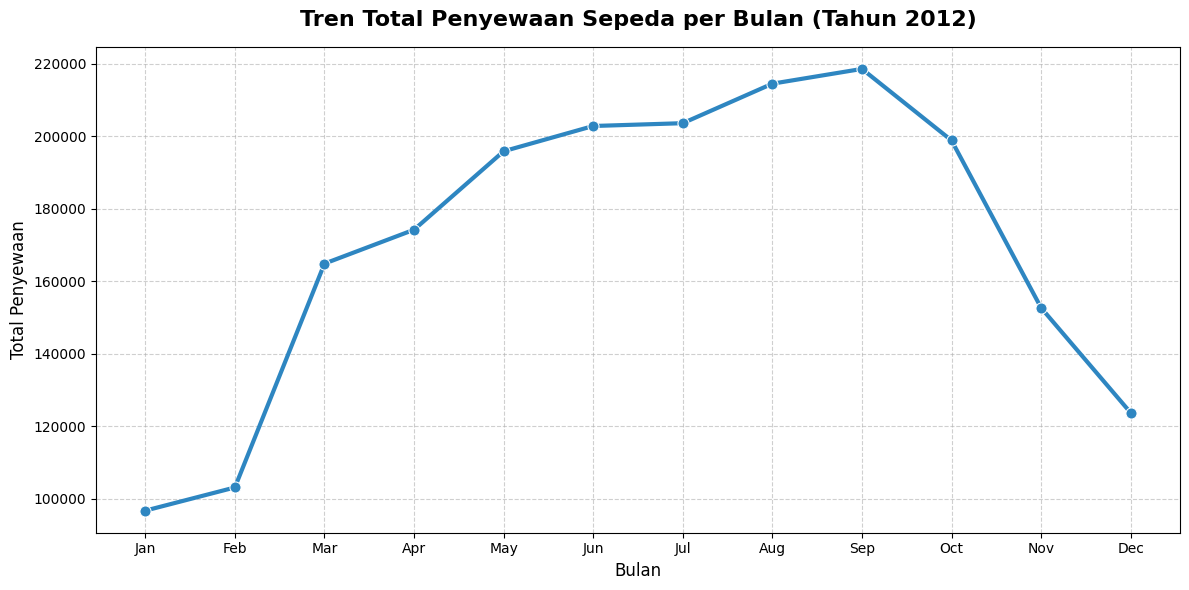

In [72]:
# VISUALIZATION 1: Tren bulanan tahun 2012 dan lonjakan tertinggi
# 1. Menyiapkan Data (Menggunakan data yang sudah dieksplorasi di EDA)
df_2012 = day_df[day_df['yr'] == '2012']
monthly_2012 = df_2012.groupby('mnth')['cnt'].sum().reset_index()

# Mengubah angka bulan menjadi singkatan nama bulan
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
monthly_2012['month_name'] = monthly_2012['mnth'].map(month_names)

# Mencari titik puncak (Peak Month)
peak_month = monthly_2012.loc[monthly_2012['cnt'].idxmax()]

# 2. Membuat Visualisasi Line Chart
plt.figure(figsize=(12, 6))
sns.lineplot(x='month_name', y='cnt', data=monthly_2012, marker='o',
             linewidth=3, color='#2E86C1', markersize=8)

plt.title('Tren Total Penyewaan Sepeda per Bulan (Tahun 2012)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Penyewaan', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Berdasarkan grafik garis di atas, terlihat bahwa tren jumlah penyewaan sepeda selama tahun 2012 mengalami peningkatan secara bertahap dari awal tahun dan mencapai puncaknya pada bulan September. Setelah melewati bulan September, angka penyewaan mengalami penurunan yang cukup drastis saat memasuki musim dingin di akhir tahun (November - Desember).

### Pertanyaan 2:

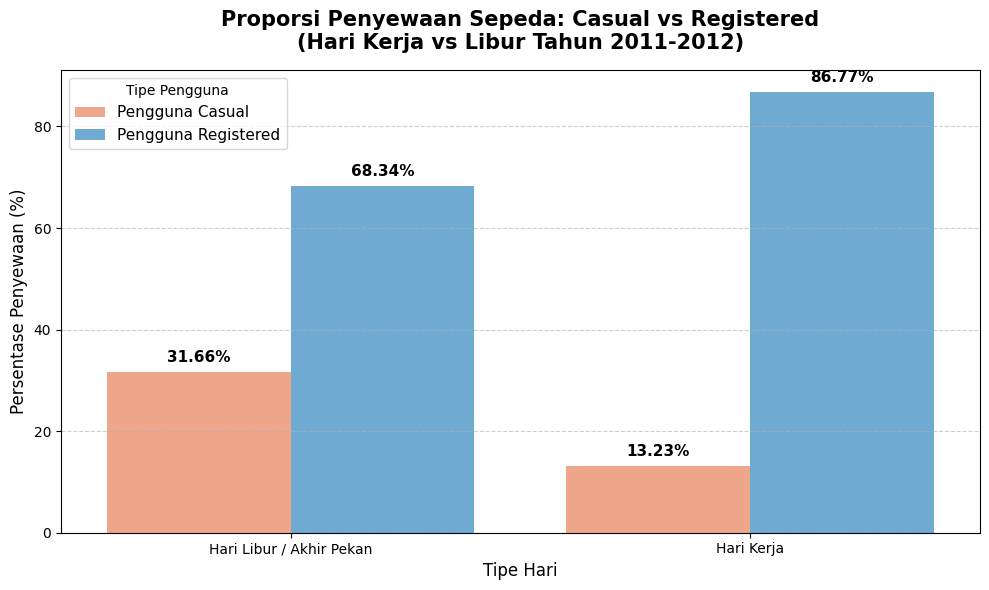

In [73]:
# VISUALIZATION 2: Proporsi Casual vs Registered (Hari Kerja vs Libur)

# 1. Menyiapkan Data (Me-melt data persentase dari tabel user_behavior sebelumnya)
user_behavior_melted = user_behavior.melt(
    id_vars='workingday',
    value_vars=['casual_percentage (%)', 'registered_percentage (%)'],
    var_name='user_type',
    value_name='percentage'
)

# Merapikan nama label untuk legenda
user_behavior_melted['user_type'] = user_behavior_melted['user_type'].map({
    'casual_percentage (%)': 'Pengguna Casual',
    'registered_percentage (%)': 'Pengguna Registered'
})

# 2. Membuat Visualisasi Grouped Bar Chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='workingday',
    y='percentage',
    hue='user_type',
    data=user_behavior_melted,
    palette=['#FFA07A', '#5DADE2'] # Menggunakan warna asli pilihan Anda
)

# Menambahkan Judul dan Label
plt.title('Proporsi Penyewaan Sepeda: Casual vs Registered\n(Hari Kerja vs Libur Tahun 2011-2012)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Tipe Hari', fontsize=12)
plt.ylabel('Persentase Penyewaan (%)', fontsize=12)

# 3. Menambahkan angka persentase tepat di atas setiap batang grafik
for p in ax.patches:
    height = p.get_height()

    # Tambahkan syarat ini agar angka 0.00% yang nyasar tidak ikut tertulis
    if height > 0:
        ax.annotate(f'{height:.2f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=11, fontweight='bold', color='black', xytext=(0, 5),
                    textcoords='offset points')

# Merapikan legenda dan grid
plt.legend(title='Tipe Pengguna', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Menampilkan grafik
plt.show()

Berdasarkan grafik di atas, terlihat sangat jelas adanya lonjakan proporsi penyewa casual pada hari libur/akhir pekan dibandingkan dengan hari kerja. Visualisasi ini menegaskan temuan sebelumnya bahwa pelanggan casual lebih aktif menyewa sepeda untuk rekreasi di akhir pekan. Oleh karena itu, pengalokasian dana promosi untuk program konversi membership dan pemberian diskon khusus akan mencapai Return on Investment (ROI) yang paling optimal jika difokuskan pada hari libur atau akhir pekan.

**Insight:**

**1. Tren Pertumbuhan dan Titik Puncak (Tahun 2012):**
* Melalui grafik garis, terlihat jelas bahwa bisnis penyewaan sepeda memiliki ketergantungan yang kuat pada faktor musiman.
* Kenaikan konsisten dari bulan Mei hingga puncaknya di **September** menunjukkan bahwa kuartal kedua dan ketiga adalah masa panen (*Peak Season*). Penurunan drastis di akhir tahun mengonfirmasi bahwa cuaca dingin menjadi hambatan utama bagi pengguna.

**2. Perilaku Pengguna dan Strategi Konversi (Tahun 2011-2012):**

* Terdapat perbedaan pola penggunaan yang sangat jelas: hari kerja secara masif didominasi oleh pelanggan *registered* (kemungkinan untuk mobilitas bekerja/sekolah), sedangkan persentase pelanggan *casual* mengalami lonjakan drastis pada hari libur atau akhir pekan untuk rekreasi.
* Sebagai tindak lanjut strategis, kampanye promosi diskon dan program penawaran konversi *membership* harus dieksekusi secara agresif khusus pada akhir pekan dan hari libur nasional. Langkah ini merupakan cara paling efektif sasaran untuk memikat pengguna kasual dan mengubah mereka menjadi pelanggan tetap guna meningkatkan keuntungan jangka panjang.


## Analisis Lanjutan (Opsional)

CLUSTERING (MANUAL GROUPING / BINNING)
- Tujuan: Mengelompokkan hari berdasarkan tingkat okupansi sepeda dan untuk menentukan prioritas perawatan armada.

In [74]:
# 1. Menentukan kriteria binning berdasarkan kuartil data
# Kita melihat distribusi 'cnt' untuk menentukan ambang batas yang objektif
low_threshold = day_df['cnt'].quantile(0.25)
high_threshold = day_df['cnt'].quantile(0.75)

def manual_clustering(cnt):
    if cnt < low_threshold:
        return 'Low Demand (Quiet Day)'
    elif cnt <= high_threshold:
        return 'Medium Demand (Typical Day)'
    else:
        return 'High Demand (Peak Day)'

# 2. Menerapkan fungsi binning
day_df['demand_cluster'] = day_df['cnt'].apply(manual_clustering)

# 3. Menghitung profil setiap cluster
cluster_profile = day_df.groupby('demand_cluster').agg({
    'cnt': ['count', 'mean', 'max'],
    'temp': 'mean',
    'hum': 'mean'
}).reset_index()

print("Profil Karakteristik Setiap Cluster Permintaan:")
display(cluster_profile)

Profil Karakteristik Setiap Cluster Permintaan:


demand_cluster   cnt                         temp       hum
                               count         mean   max      mean      mean
0       High Demand (Peak Day)   183  7042.448087  8714  0.620569  0.608429
1       Low Demand (Quiet Day)   183  1933.579235  3141  0.308944  0.637960
2  Medium Demand (Typical Day)   365  4520.728767  5936  0.526097  0.632606

 ANALISIS LANJUTAN: RFM ANALYSIS
- Tujuan: Menganalisis 'kesehatan' bisnis berdasarkan waktu penyewaan terakhir (Recency), intensitas hari ramai (Frequency), dan total volume penyewaan (Monetary).

In [75]:
# Mengambil tanggal referensi untuk Recency (Hari terakhir di dataset)
recent_date = day_df['dteday'].max()

# Kita asumsikan 'Frequency' adalah jumlah hari unik penyewaan terjadi
# Dan 'Monetary' adalah jumlah total sepeda yang disewa (cnt)
# Kita kelompokkan berdasarkan hari dalam seminggu (weekday) untuk melihat performa mingguan
rfm_df = day_df.groupby('weekday').agg({
    'dteday': lambda x: (recent_date - x.max()).days, # Recency: hari sejak sewa terakhir
    'instant': 'count',                              # Frequency: seberapa sering hari tersebut muncul
    'cnt': 'sum'                                     # Monetary: total pendapatan volume
}).reset_index()

# Merapikan nama kolom
rfm_df.columns = ['Weekday', 'Recency (Days)', 'Frequency (Days Count)', 'Monetary (Total Count)']

# Mengubah angka hari menjadi nama hari agar informatif
day_map = {0:'Minggu', 1:'Senin', 2:'Selasa', 3:'Rabu', 4:'Kamis', 5:'Jumat', 6:'Sabtu'}
rfm_df['Weekday'] = rfm_df['Weekday'].map(day_map)

print("Tabel RFM Berdasarkan Hari dalam Seminggu:")
display(rfm_df)

Tabel RFM Berdasarkan Hari dalam Seminggu:


,Weekday,Recency (Days),Frequency (Days Count),Monetary (Total Count)
0,Minggu,1,105,444027
1,Senin,0,105,455503
2,Selasa,6,104,469109
3,Rabu,5,104,473048
4,Kamis,4,104,485395
5,Jumat,3,104,487790
6,Sabtu,2,105,477807


ANALISIS LANJUTAN 3: TIME SERIES ANALYSIS (MOVING AVERAGE)
- Tujuan: Menghilangkan fluktuasi harian (noise) untuk melihat tren pergerakan jangka panjang menggunakan metode penghalusan (smoothing) 7-Hari dan 30-Hari.



In [76]:
# 1. Memastikan data sudah terurut berdasarkan tanggal
# (Sangat penting untuk analisis deret waktu)
day_df = day_df.sort_values(by='dteday')

# 2. Menghitung Rata-rata Bergerak (Moving Average)
# Window=7 artinya rata-rata dari 7 hari ke belakang (mewakili tren mingguan)
# Window=30 mewakili tren bulanan
day_df['7_day_MA'] = day_df['cnt'].rolling(window=7).mean()
day_df['30_day_MA'] = day_df['cnt'].rolling(window=30).mean()

# 3. Menampilkan hasil perhitungan
print("Insight Time Series Analysis (Moving Average):")
print("Kolom '7_day_MA' dan '30_day_MA' berhasil ditambahkan untuk melihat tren yang lebih halus.")
display(day_df[['dteday', 'cnt', '7_day_MA', '30_day_MA']].tail(10))

Insight Time Series Analysis (Moving Average):
Kolom '7_day_MA' dan '30_day_MA' berhasil ditambahkan untuk melihat tren yang lebih halus.


,dteday,cnt,7_day_MA,30_day_MA
721,2012-12-22,1749,4099.285714,4746.166667
722,2012-12-23,1787,3813.714286,4675.400000
723,2012-12-24,920,3290.142857,4630.166667
724,2012-12-25,1013,2641.000000,4583.133333
725,2012-12-26,441,1951.571429,4428.266667
726,2012-12-27,2114,1663.857143,4366.766667
727,2012-12-28,3095,1588.428571,4294.600000
728,2012-12-29,1341,1530.142857,4161.866667
729,2012-12-30,1796,1531.428571,4032.800000
730,2012-12-31,2729,1789.857143,3950.733333


**Insight :**

**1. Insight dari Clustering (Manual Grouping / Binning):**
* Dengan mengelompokkan hari berdasarkan ambang batas kuartil, kita membagi operasional menjadi tiga kondisi: *Low Demand* (Sepi), *Medium Demand* (Normal), dan *High Demand* (Puncak).
* **Tindakan Bisnis:** Tim operasional dapat menggunakan profil kelompok ini sebagai SOP (Standar Operasional Prosedur). Misalnya, hari dengan prediksi cuaca buruk yang masuk kategori *Low Demand* dapat dimanfaatkan secara maksimal untuk menarik armada ke bengkel guna pemeliharaan besar-besaran tanpa mengganggu ketersediaan sepeda di pasar.

**2. Insight dari RFM Analysis (Berdasarkan Hari):**
* Melalui modifikasi metrik RFM pada skala hari (Weekday), kita melihat bahwa parameter *Monetary* (Total volume sewa) memiliki distribusi yang bervariasi antar hari.
* **Tindakan Bisnis:** Hari dengan nilai *Monetary* tertinggi (seperti akhir pekan atau hari kerja tertentu tergantung segmen pengguna) harus diantisipasi dengan distribusi staf lapangan yang lebih banyak untuk memastikan rotasi sepeda antar stasiun berjalan lancar.

**3. Insight dari Time Series (Moving Average):**
* Teknik *smoothing* dengan jendela 7-hari (mingguan) dan 30-hari (bulanan) berhasil menghilangkan "kebisingan" atau lonjakan tajam harian (misalnya akibat hujan tiba-tiba atau libur nasional).
* **Tindakan Bisnis:** Garis tren makro (*Moving Average* 30-hari) membuktikan secara solid bahwa secara keseluruhan bisnis ini memiliki pola pertumbuhan kuartalan yang konsisten memuncak di musim gugur. Ini sangat berguna bagi investor atau pemegang saham untuk melihat kesehatan bisnis secara garis besar tanpa terdistraksi masalah operasional harian.

## Conclusion

**1. Jawaban Pertanyaan 1: Tren Fluktuasi 2012 & Puncak Permintaan**
Analisis tren menunjukkan bahwa penyewaan sepeda sangat dipengaruhi oleh faktor musiman. Sepanjang tahun 2012, permintaan membentuk pola kurva yang meningkat pesat sejak kuartal kedua dan mencapai **titik puncak tertinggi pada bulan September**. Hal ini membuktikan bahwa cuaca yang mendukung (musim gugur/panas) adalah pendorong utama volume bisnis. Penurunan tajam di akhir tahun memberikan sinyal bagi perusahaan untuk menyesuaikan kapasitas operasional selama musim dingin agar tetap efisien secara biaya.

**2. Jawaban Pertanyaan 2: Perilaku Pengguna & Strategi Konversi**
Terdapat perbedaan proporsi yang sangat signifikan antara pelanggan berdasarkan tipe hari selama periode 2011-2012. Pada hari kerja, penyewaan didominasi oleh pelanggan registered (86.77%), yang menunjukkan penggunaan untuk mobilitas rutin. Sebaliknya, pada hari libur/akhir pekan, proporsi pelanggan casual melonjak tajam hingga 31.66% untuk tujuan rekreasi. Sebagai tindak lanjut strategis, perusahaan harus memfokuskan program penawaran diskon dan kampanye konversi membership secara agresif pada akhir pekan dan hari libur nasional. Langkah ini adalah cara paling efektif dan tepat sasaran untuk menjaring pengguna casual menjadi pelanggan tetap demi meningkatkan pendapatan jangka panjang perusahaan.


**3. Hasil Analisis Lanjutan (Clustering, RFM, & Time Series)**
* Melalui **Clustering**, kita kini memiliki klasifikasi hari (*High, Medium, Low Demand*) yang dapat digunakan sebagai basis alokasi sumber daya manusia dan armada.
* Analisis **RFM** mempertegas bahwa performa bisnis sangat bergantung pada hari-hari tertentu dalam seminggu, yang memungkinkan tim manajemen melakukan pengawasan (*monitoring*) yang lebih presisi.
* Teknik **Time Series Smoothing** (Moving Average) memberikan pandangan jangka panjang yang optimis, di mana tren bisnis secara keseluruhan menunjukkan pertumbuhan yang sehat meski terdapat fluktuasi harian yang dinamis.

In [78]:
# Menyimpan data yang sudah dibersihkan untuk keperluan Dashboard
day_df.to_csv("main_data.csv", index=False)

print("Data berhasil disimpan sebagai main_data.csv!")

Data berhasil disimpan sebagai main_data.csv!
